In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()
import operator

In [32]:
generator_llm = ChatOpenAI(model = 'gpt-4o-mini')
optimizer_llm = ChatOpenAI(model = 'gpt-4o-mini')
evaluator_llm = ChatOpenAI(model = 'gpt-4o-mini')

In [33]:
class EvaluationSchema(BaseModel):
    evaluation: Literal['approved', 'needs_improvement'] = Field(description = 'Evaluation result of the tweet')
    feedback : str = Field(description = 'Constructive feedback for the tweet')

In [34]:
evaluator_model = evaluator_llm.with_structured_output(EvaluationSchema)

In [35]:
class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal['approved', 'needs_improvement']
    feedback : str
    iteration : int
    max_iteration: int

    tweet_history : Annotated[list[str], operator.add]
    feedback_history : Annotated[list[str], operator.add]

In [36]:
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english """)
    ]

    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history' : [response]}


In [37]:
def evaluate_tweet(state : TweetState):
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor,originality, virality, and tweet format."),
        HumanMessage (content=f"""Evaluate the following tweet:
        Tweet: "{state[ 'tweet']}"
        Use the criteria below to evaluate the tweet:
        1. Originality - Is this fresh, or have you seen it a hundred times before?
        2. Humor - Did it genuinely make you smile, laugh, or chuckle?
        3. Punchiness - Is it short, sharp, and scroll-stopping?
        4. Virality Potential - Would people retweet or share it?
        5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?
        Auto-reject if:
        - It's written in question-answer format (e.g., "Why |did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)
        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"
        feedback: One paragraph explaining the strengths and weaknesses"""
        )
    ]
    response = evaluator_model.invoke(messages)

    return {'evaluation' : response.evaluation, 'feedback': response.feedback, 'feedback_history' : [response.feedback]}

In [38]:
def optimize_tweet(state : TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage (content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"
        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}
        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.""")
        ]
    
    response = optimizer_llm.invoke(messages).content

    return {'tweet' : response, 'iteration' : state['iteration']+1, 'tweet_history' : [response]}

In [39]:
def route_evaluation(state : TweetState) -> Literal[END, 'optimize_tweet']:
    if state['evaluation'] == 'approved' or state['iteration'] > state['max_iteration']:
        return END
    else :
        return 'optimize_tweet'

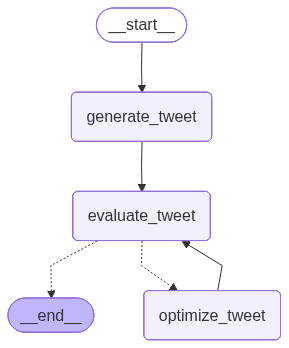

In [40]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route_evaluation)
graph.add_edge('optimize_tweet','evaluate_tweet')

workflow = graph.compile()

workflow

In [41]:
initial_state = {
    'topic' : 'qwertyuiop',
    'max_iteration' : 3,
    'iteration' : 0
}

response = workflow.invoke(initial_state)

response

{'topic': 'qwertyuiop',
 'tweet': '"QWERTYUIOP: It’s like a toddler’s finger painting—chaotic, vibrant, and somehow missing a finger. Just a caffeine-fueled circus where ‘thanks’ disappears into the keyboard abyss! 🎪☕️ #CaffeinatedChaos #KeyboardArt"',
 'evaluation': 'approved',
 'feedback': "This tweet excels in originality, presenting an imaginative comparison between a keyboard layout and a toddler's finger painting. The unexpected imagery effectively evokes humor and captures attention, contributing to its punchiness. The playful description of chaotic creativity and the unique twist on the phrase about keyboard functionality makes it relatable for many caffeine enthusiasts. The inclusion of emojis enhances the visual appeal and overall engagement potential. Moreover, it is well-structured, adhering to the character limit without resorting to clichéd expressions or traditional joke formats, making it shareable and likely to resonate with a broad audience.",
 'iteration': 3,
 'max_i

In [43]:
for i, (tweet, feedback) in enumerate(zip(response['tweet_history'], response['feedback_history']), 1):
    print(f"--- Iteration {i} ---")
    print(f"Tweet: {tweet}")
    print(f"Feedback: {feedback}\n")

--- Iteration 1 ---
Tweet: "QWERTYUIOP: the keyboard equivalent of a toddler’s drawing. Somehow both chaotic and essential, like my coffee addiction and my ability to send 50 emails without a single 'thanks' or 'goodbye.' Basically, it’s just vibes and finger gymnastics. 💻👌"
Feedback: The tweet has an interesting premise with an original metaphor comparing the keyboard layout to a toddler’s drawing, which displays some creativity. However, the humor falls flat as it doesn’t evoke a strong reaction; the references to coffee addiction and email etiquette feel overstuffed and somewhat cliché. Additionally, the tweet lacks punchiness; it’s a bit meandering and could benefit from being more concise to sharpen its impact. While there are elements of relatability that could make it shareable, overall, it doesn’t strike the right balance of humor and clarity to achieve virality.

--- Iteration 2 ---
Tweet: "QWERTYUIOP: the keyboard version of a toddler's finger painting—chaotic yet somehow ess